<a href="https://colab.research.google.com/github/gunjancs23149/Machine-Learing-Project/blob/main/SVR__Gunjan_CS23149.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task
Perform electric load forecasting using an SVR model on the dataset located at "/content/drive/MyDrive/TG-NPDCL_consumption_detail_commercial_JANUARY-2025.csv". This task involves data preprocessing, feature engineering, training an SVR model, evaluating its performance with metrics like MAE, MSE, and R-squared, and visualizing the predictions.

## Import Libraries



In [1]:
import numpy as np
from sklearn.svm import SVC, SVR
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("Required libraries imported successfully.")

Required libraries imported successfully.


## 1 Mount Google Drive



In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Load Dataset



In [3]:
import pandas as pd

file_path = '/content/drive/MyDrive/TG-NPDCL_consumption_detail_commercial_JANUARY-2025.csv'
df = pd.read_csv(file_path)

print("Dataset loaded successfully. Displaying the first 5 rows:")
df.head()

Dataset loaded successfully. Displaying the first 5 rows:


,Circle,Division,SubDivision,Section,Area,CatCode,CatDesc,TotServices,BilledServices,Units,Load
0,WARANGAL,RURAL WARANGAL,WARDHANNAPET,MYLARAM,JAYARAM THANDA-1,2,COMMERCIAL,5,5,84,11.000
1,WARANGAL,WARANGAL,WARANGAL,STATION ROAD,NIZAMPURA-II,2,COMMERCIAL,392,334,44762,872.100
2,WARANGAL,WARANGAL,WARANGAL,STATION ROAD,OSMAN GANJ,2,COMMERCIAL,492,431,31931,568.730
3,WARANGAL,WARANGAL,WARANGAL,STATION ROAD,PETROL PUMP,2,COMMERCIAL,458,407,28871,657.578
4,WARANGAL,WARANGAL,WARANGAL,STATION ROAD,RAMOLLAWADA,2,COMMERCIAL,326,262,111598,2199.410


## Data Preprocessing and Feature Engineering



In [4]:
print("DataFrame Info:")
df.info()

print("\nMissing values per column:")
df.isnull().sum()

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8335 entries, 0 to 8334
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Circle          8335 non-null   object 
 1   Division        8335 non-null   object 
 2   SubDivision     8335 non-null   object 
 3   Section         8335 non-null   object 
 4   Area            8335 non-null   object 
 5   CatCode         8335 non-null   int64  
 6   CatDesc         8335 non-null   object 
 7   TotServices     8335 non-null   int64  
 8   BilledServices  8335 non-null   int64  
 9   Units           8335 non-null   int64  
 10  Load            8335 non-null   float64
dtypes: float64(1), int64(4), object(6)
memory usage: 716.4+ KB

Missing values per column:


,0
Circle,0
Division,0
SubDivision,0
Section,0
Area,0
CatCode,0
CatDesc,0
TotServices,0
BilledServices,0
Units,0


In [5]:
categorical_cols = ['Circle', 'Division', 'SubDivision', 'Section', 'Area', 'CatDesc']
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Define features (X) and target (y)
X = df_encoded.drop('Load', axis=1)
y = df_encoded['Load']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Shape of X_train_scaled: {X_train_scaled.shape}")
print(f"Shape of X_test_scaled: {X_test_scaled.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")
print("Data preprocessing and feature engineering completed.")

Shape of X_train_scaled: (6668, 7856)
Shape of X_test_scaled: (1667, 7856)
Shape of y_train: (6668,)
Shape of y_test: (1667,)
Data preprocessing and feature engineering completed.


## Train SVR Model



In [6]:
svr_model = SVR(kernel='rbf')
svr_model.fit(X_train_scaled, y_train)

print("SVR model trained successfully.")

SVR model trained successfully.


## Evaluate Model Performance



In [7]:
y_pred = svr_model.predict(X_test_scaled)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Model Evaluation on Test Set:")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"R-squared (R2): {r2:.4f}")

Model Evaluation on Test Set:
Mean Absolute Error (MAE): 145.0434
Mean Squared Error (MSE): 288718.9144
R-squared (R2): -0.0591


## Visualize Predictions



In [8]:
import matplotlib.pyplot as plt

print("Matplotlib imported successfully.")

Matplotlib imported successfully.


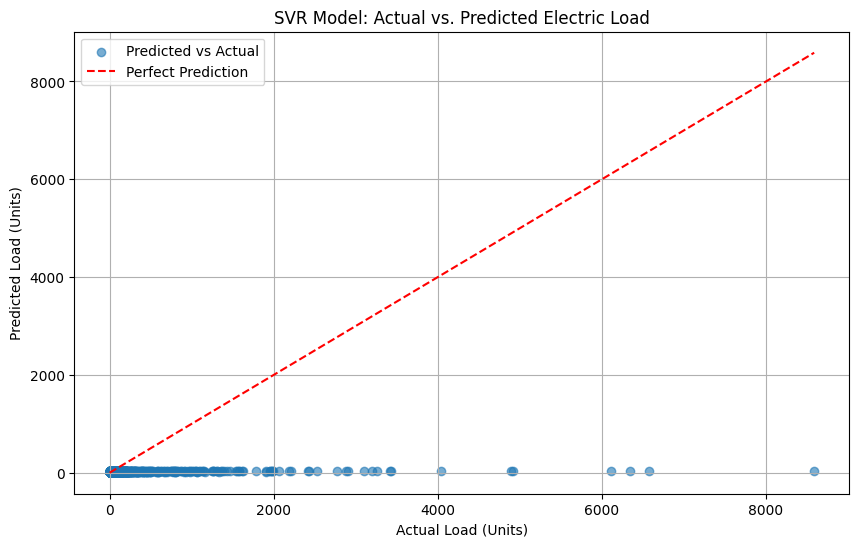

Prediction visualization completed.


In [9]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.6, label='Predicted vs Actual')

# Add a line for perfect predictions
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Perfect Prediction')

plt.xlabel('Actual Load (Units)')
plt.ylabel('Predicted Load (Units)')
plt.title('SVR Model: Actual vs. Predicted Electric Load')
plt.legend()
plt.grid(True)
plt.show()

print("Prediction visualization completed.")

In [10]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from IPython.display import display

# Re-loading the dataframe to ensure it's defined in the current scope
# (Assuming 'df' is available from prior execution, but adding this for robustness)
if 'df' not in locals():
    file_path = '/content/drive/MyDrive/TG-NPDCL_consumption_detail_commercial_JANUARY-2025.csv'
    df = pd.read_csv(file_path)

def prepare_data(df, test_size):
    """Splits data, applies one-hot encoding, and scales features."""
    categorical_cols = ['Circle', 'Division', 'SubDivision', 'Section', 'Area', 'CatDesc']
    df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

    X = df_encoded.drop('Load', axis=1)
    y = df_encoded['Load']

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=42)

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    return X_train_scaled, X_test_scaled, y_train, y_test

def train_and_evaluate_model(model, X_train_scaled, X_test_scaled, y_train, y_test):
    """Trains a model, makes predictions, and calculates evaluation metrics."""
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    metrics = {
        'MAE': mae,
        'MSE': mse,
        'R2': r2
    }
    return metrics

print("Data preparation and model training/evaluation functions defined.")

# --- 80:20 Split ---
print("\n--- Processing 80:20 Split (test_size=0.2) ---")
X_train_scaled_0_2, X_test_scaled_0_2, y_train_0_2, y_test_0_2 = prepare_data(df, test_size=0.2)

svr_model_0_2 = SVR(kernel='rbf')
metrics_0_2 = train_and_evaluate_model(svr_model_0_2, X_train_scaled_0_2, X_test_scaled_0_2, y_train_0_2, y_test_0_2)

print("SVR Model Evaluation (80:20 Split):")
metrics_df_0_2 = pd.DataFrame(metrics_0_2.items(), columns=['Metric', 'Value'])
metrics_df_0_2.rename(columns={'Value': '80:20 Split'}, inplace=True)
display(metrics_df_0_2.round(4))

# --- 70:30 Split ---
print("\n--- Processing 70:30 Split (test_size=0.3) ---")
X_train_scaled_0_3, X_test_scaled_0_3, y_train_0_3, y_test_0_3 = prepare_data(df, test_size=0.3)

svr_model_0_3 = SVR(kernel='rbf')
metrics_0_3 = train_and_evaluate_model(svr_model_0_3, X_train_scaled_0_3, X_test_scaled_0_3, y_train_0_3, y_test_0_3)

print("SVR Model Evaluation (70:30 Split):")
metrics_df_0_3 = pd.DataFrame(metrics_0_3.items(), columns=['Metric', 'Value'])
metrics_df_0_3.rename(columns={'Value': '70:30 Split'}, inplace=True)
display(metrics_df_0_3.round(4))

Data preparation and model training/evaluation functions defined.

--- Processing 80:20 Split (test_size=0.2) ---
SVR Model Evaluation (80:20 Split):


,Metric,80:20 Split
0,MAE,145.0434
1,MSE,288718.9144
2,R2,-0.0591



--- Processing 70:30 Split (test_size=0.3) ---
SVR Model Evaluation (70:30 Split):


,Metric,70:30 Split
0,MAE,140.4522
1,MSE,261981.3701
2,R2,-0.0620
